# Weight/mass loss Predictor

**Author:** Lab of Farm Structures
**Date:** 2026-01

## Import libraries

In [1]:
import pandas as pd
import kennard_stone as ks
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
import shap
from prince import FAMD
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
import seaborn as sns
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox, MeanVar

## Load data

In [2]:
model_weight = 'weight_loss_data_LM_new'

df_weight = pd.read_csv(f'{model_weight}.csv')
df_weight.tail()

,degradation_time_days,weight_loss,study_id,instance,phb_initial_mol,phv_initial_mol,degradation_condition,degradation_mechanism,additives,t_deg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,additive_type_3,additive3_percentage_wt,sample_shape_morphology,pha_degrading_microbes,experimental_scale
1531,135.0,73.0,24.0,8,98.0,2.0,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,lab
1532,141.0,74.0,24.0,8,98.0,2.0,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,lab
1533,148.0,75.0,24.0,8,98.0,2.0,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,lab
1534,155.0,76.0,24.0,8,98.0,2.0,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,lab
1535,161.0,76.0,24.0,8,98.0,2.0,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,lab


## Exclude randomly one instance from multi-instance studies

In [3]:
np.random.seed(42)

# Count rows per Study_id and Instance
instance_row_counts = (
    df_weight.groupby(['study_id', 'instance'])
    .size()  # counts rows per Study_id-Instance
)

# Keep only instances with at least 5 rows
valid_instances = instance_row_counts[instance_row_counts >= 5]

# Study_ids with more than one instance
instance_counts = valid_instances.groupby('study_id').size()

# Keep only Study_ids with more than one valid instance
multi_study_ids = instance_counts[instance_counts > 2].index

# Randomly select ONE instance per such Study_id
excluded_instances = (
    df_weight[df_weight['study_id'].isin(multi_study_ids)]
    .groupby('study_id')['instance']
    .apply(lambda x: np.random.choice(x.unique()))
    .reset_index(name='Excluded_Instance')
)

# reduce the amount of val set
excluded_instances = excluded_instances[
    ~excluded_instances['study_id'].isin([9,14,19])
]

# Merge back to create a row-aligned mask
df_with_exclusion = df_weight.merge(
    excluded_instances,
    on='study_id',
    how='left'
)

# Rows to exclude: those matching the randomly selected instance
exclude_mask = df_with_exclusion['instance'] == df_with_exclusion['Excluded_Instance']

# Split the dataframes
df_val = df_with_exclusion[exclude_mask].drop(columns='Excluded_Instance')
df_weight = df_with_exclusion[~exclude_mask].drop(columns='Excluded_Instance')

print(df_val[['study_id', 'instance']].drop_duplicates())

      study_id instance
394       12.0        4
625       13.0        5
809       15.0        6
1022      18.0       3b
1434      21.0        5
1490      24.0        7


In [4]:
print('train/test set size:', df_weight.shape, '\n Val set size',df_val.shape)

train/test set size: (1365, 20) 
 Val set size (171, 20)


## Select Features and Target

In [5]:
features = [
    'phb_initial_mol',
    'phv_initial_mol',
    'degradation_time_days',
    'degradation_condition',
    'degradation_mechanism',
    't_deg',
    'degradation_environment',
    'additive_type_1',
    'additive1_percentage_wt',
    'additive_type_2',
    'additive2_percentage_wt',
    'additive_type_3',
    'additive3_percentage_wt',
    'pha_degrading_microbes',
    'sample_shape_morphology',
    'experimental_scale'
]

target = 'weight_loss'

measure_unit = '%'

In [6]:
# Create DataFrame
df_new = df_weight[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.tail()

,phb_initial_mol,phv_initial_mol,degradation_time_days,degradation_condition,degradation_mechanism,t_deg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,additive_type_3,additive3_percentage_wt,pha_degrading_microbes,sample_shape_morphology,experimental_scale,weight_loss
1531,98.0,2.0,135.0,aerobic,hydrolysis,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,lab,73.0
1532,98.0,2.0,141.0,aerobic,hydrolysis,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,lab,74.0
1533,98.0,2.0,148.0,aerobic,hydrolysis,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,lab,75.0
1534,98.0,2.0,155.0,aerobic,hydrolysis,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,lab,76.0
1535,98.0,2.0,161.0,aerobic,hydrolysis,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,lab,76.0


In [7]:
df_final.shape

(1365, 17)

In [8]:
# numerical columns
numerical_cols_lst = df_final.select_dtypes(include=[np.number]).columns.tolist()
# categorical columns 
categorical_cols_lst = df_final.select_dtypes(include=['object', 'category']).columns.tolist()

## Plot feature distribution

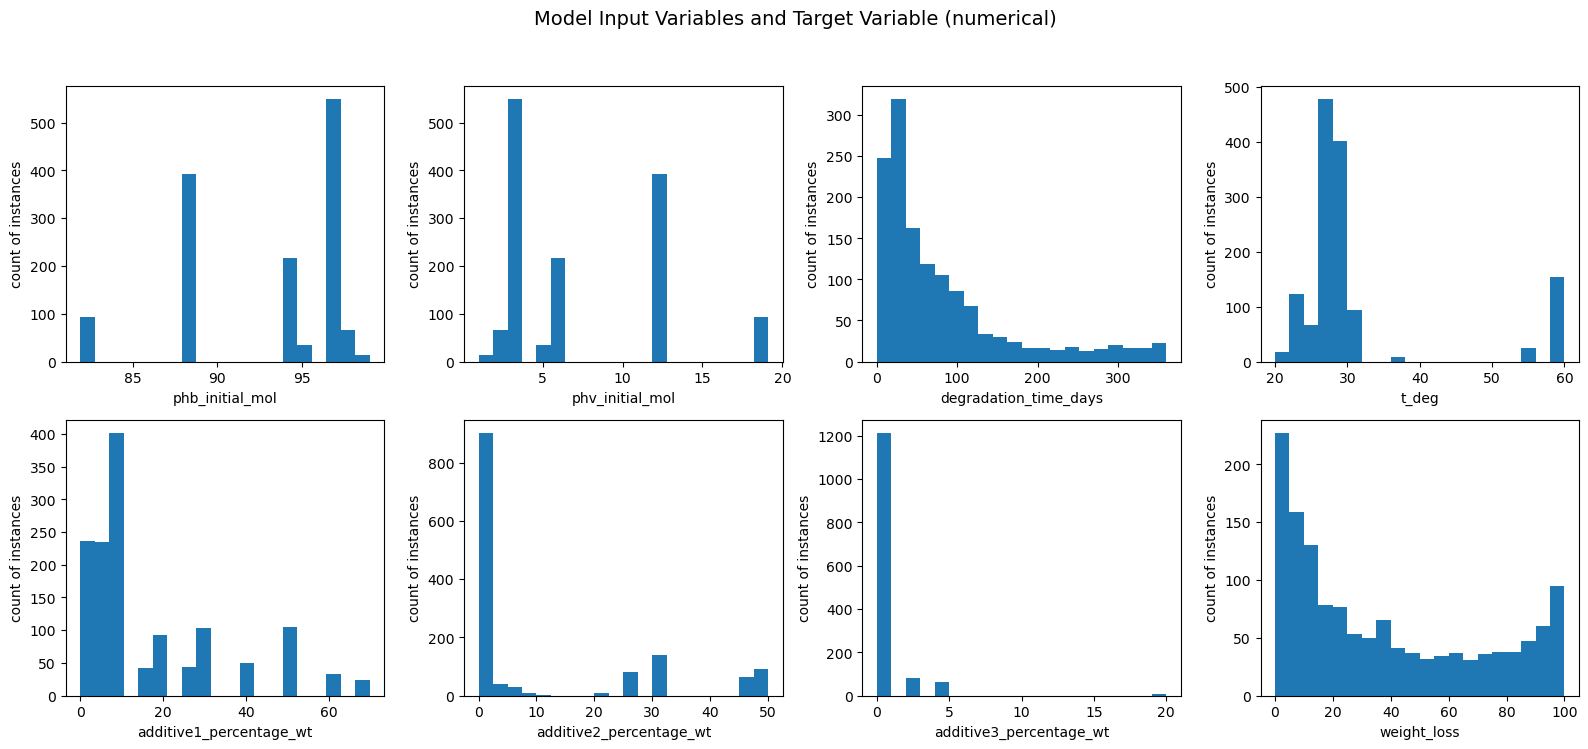

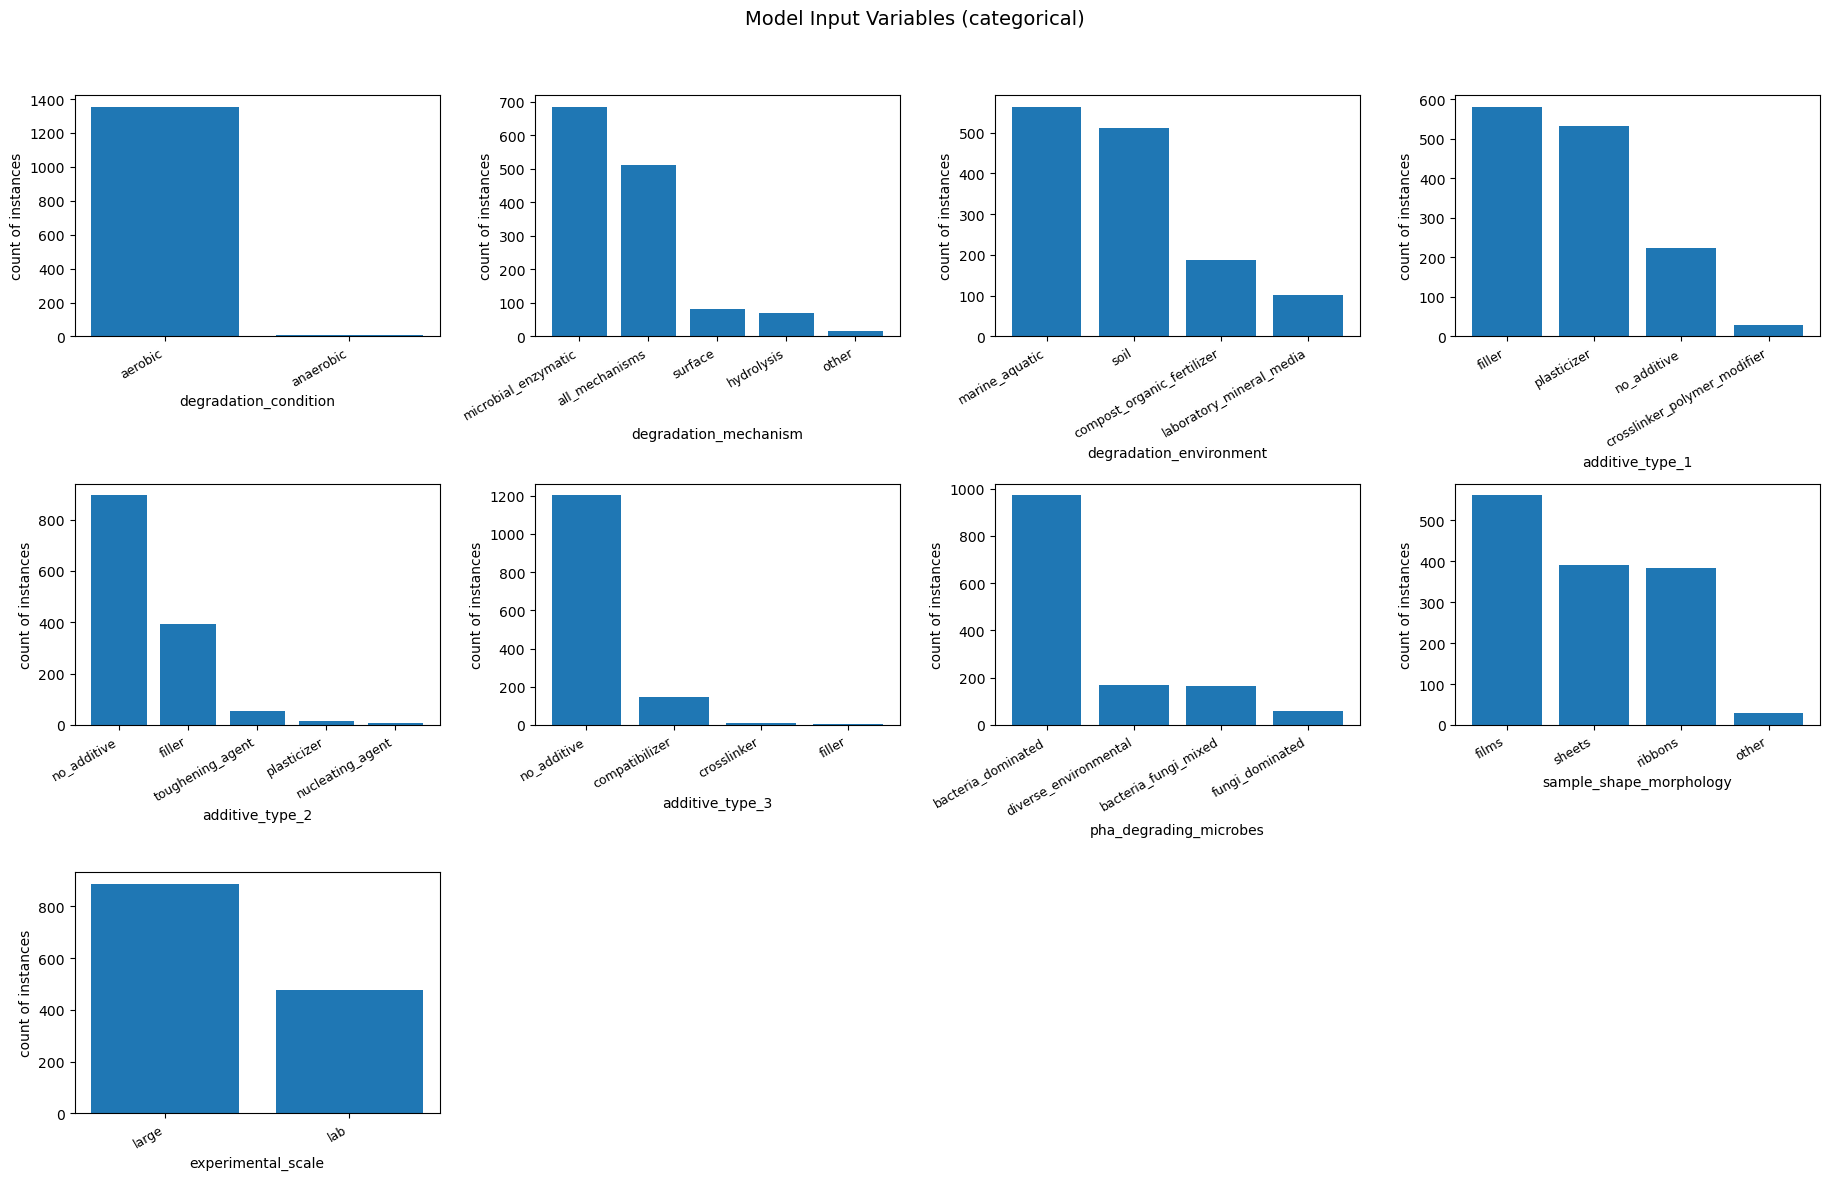

In [9]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()



plot_feature_distributions(
    df_final,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

## Correlation matrix of numerical features

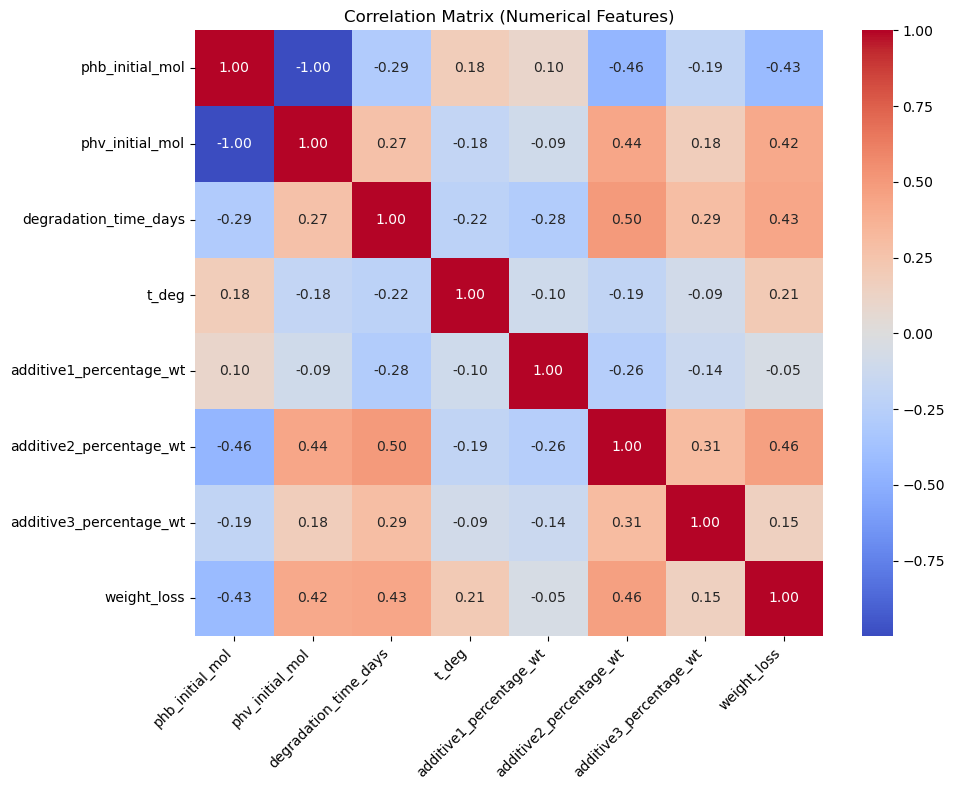

In [10]:
numerical_df = df_final[numerical_cols_lst]

# Compute correlation matrix
corr_matrix = numerical_df.corr() 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(rotation=45, ha="right") 
plt.yticks(rotation=0) 

plt.tight_layout()
# plt.savefig("correlation.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

In [11]:
df_final.drop(columns=['phv_initial_mol'], inplace=True)

## Train - test splitting

In [12]:
# Separate features and target
X = df_final.drop(columns=[target]) 
y = df_final[target]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Train set size:', X_train.shape, '\n Test set size',X_test.shape)

Train set size: (1092, 15) 
 Test set size (273, 15)


## FAMD for outlier detection - only on the Train set (if applied)

In [18]:
# Fit FAMD with a reasonably high number of components
famd = FAMD(n_components=30, n_iter=10, random_state=42).fit(X_train)

eigenvalues = famd.eigenvalues_
explained_inertia = eigenvalues / eigenvalues.sum()
cumulative_inertia = np.cumsum(explained_inertia)

famd.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,21.641,18.26%,18.26%
1,15.798,13.33%,31.59%
2,12.350,10.42%,42.02%
3,10.220,8.62%,50.64%
4,7.362,6.21%,56.85%
5,6.622,5.59%,62.44%
6,6.584,5.56%,68.00%
7,5.336,4.50%,72.50%
8,4.864,4.10%,76.61%


In [19]:
# Initial FAMD for outlier detection
n_components_initial = 25
famd2 = FAMD(n_components=n_components_initial, random_state=42)
X_train_famd = famd2.fit_transform(X_train)

X_train_famd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1092 entries, 1133 to 1261
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1092 non-null   float64
 1   1       1092 non-null   float64
 2   2       1092 non-null   float64
 3   3       1092 non-null   float64
 4   4       1092 non-null   float64
 5   5       1092 non-null   float64
 6   6       1092 non-null   float64
 7   7       1092 non-null   float64
 8   8       1092 non-null   float64
 9   9       1092 non-null   float64
 10  10      1092 non-null   float64
 11  11      1092 non-null   float64
 12  12      1092 non-null   float64
 13  13      1092 non-null   float64
 14  14      1092 non-null   float64
 15  15      1092 non-null   float64
 16  16      1092 non-null   float64
 17  17      1092 non-null   float64
 18  18      1092 non-null   float64
 19  19      1092 non-null   float64
 20  20      1092 non-null   float64
 21  21      1092 non-null   float64
 22  22

In [20]:
X_train_famd_df = X_train_famd.copy()
X_train_famd_df.columns = [f'Comp{i+1}' for i in range(X_train_famd_df.shape[1])]

X_train_famd_df.tail()

,Comp1,Comp2,Comp3,Comp4,Comp5,Comp6,Comp7,Comp8,Comp9,Comp10,...,Comp16,Comp17,Comp18,Comp19,Comp20,Comp21,Comp22,Comp23,Comp24,Comp25
1230,6.045553,0.351714,-0.808773,-0.140094,0.230230,-0.569210,-0.486748,-0.104722,0.368696,-0.077512,...,-0.058962,0.354389,-0.257490,0.859758,0.160931,-0.820649,0.523535,0.211001,-0.208129,0.000649
1265,8.478535,0.605513,-1.258612,0.190471,0.943961,-1.524927,-0.045423,0.264083,-0.588118,-0.587923,...,0.058647,-0.336495,0.260320,-0.526542,-0.507231,1.059872,-0.916064,-0.391547,0.135959,0.243372
1429,-4.759266,3.654529,-4.348581,2.309763,0.996075,-0.647645,0.487232,-2.015272,0.939904,1.493439,...,3.663607,-1.067258,-0.850080,0.026948,-1.637570,-0.306162,-0.101412,0.116196,-0.336417,-0.074635
975,3.952810,0.279562,-0.558404,-0.587380,-0.107476,0.168579,-0.934604,-1.019967,0.570345,0.663527,...,-0.139617,0.069736,-0.555649,-2.826158,0.408683,-0.250348,1.162745,0.438615,-0.461786,0.074932
1261,8.355204,0.613885,-1.241275,0.185061,0.949064,-1.493083,-0.089222,0.246236,-0.585980,-0.565497,...,0.001056,-0.270108,0.276487,-0.386630,-0.223598,0.507691,-0.360758,-0.248089,0.002841,0.213101


## Outlier detection with IQR

**Test = 1:** No exclusion
**Test = 2:** +-10 IQR   **Test = 3:** +-7 IQR  

In [21]:
test = 1

# Detect outliers using IQR
def detect_iqr_outliers(df,alpha):
    outlier_indices = set()
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - alpha * IQR
        upper_bound = Q3 + alpha * IQR
        outliers_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers_col)
    return list(outlier_indices)

# Drop outliers
if test == 2:
    alpha = 10
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±2")

elif test == 3:
    alpha = 7
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±",alpha)

else:
    df_clean = df_final.copy()
    X_train_clean = X_train
    y_train_clean = y_train
    print("IQR outlier detection SKIPPED")

print(f"Original data shape: {X_train.shape}")
print(f"Cleaned data shape: {X_train_clean.shape}")

IQR outlier detection SKIPPED
Original data shape: (1092, 15)
Cleaned data shape: (1092, 15)


In [22]:
X_train_clean.tail()

,phb_initial_mol,degradation_time_days,degradation_condition,degradation_mechanism,t_deg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,additive_type_3,additive3_percentage_wt,pha_degrading_microbes,sample_shape_morphology,experimental_scale
1230,88.0,75.0,aerobic,microbial_enzymatic,26.0,marine_aquatic,plasticizer,7.0,filler,30.0,no_additive,0.0,bacteria_dominated,ribbons,large
1265,88.0,304.0,aerobic,microbial_enzymatic,26.0,marine_aquatic,plasticizer,7.0,filler,27.3,compatibilizer,2.7,bacteria_dominated,ribbons,large
1429,97.0,45.0,aerobic,microbial_enzymatic,58.0,compost_organic_fertilizer,filler,25.0,no_additive,0.0,no_additive,0.0,bacteria_fungi_mixed,films,lab
975,88.0,76.0,aerobic,microbial_enzymatic,29.0,marine_aquatic,plasticizer,10.0,no_additive,0.0,no_additive,0.0,bacteria_dominated,ribbons,large
1261,88.0,227.0,aerobic,microbial_enzymatic,26.0,marine_aquatic,plasticizer,7.0,filler,27.3,compatibilizer,2.7,bacteria_dominated,ribbons,large


## One-hot encoding

In [70]:
X_train = X_train_clean.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None)
ohe.fit(X_train[categorical_cols_lst])

# Transform
X_train_ohe = ohe.transform(X_train[categorical_cols_lst])
X_test_ohe = ohe.transform(X_test[categorical_cols_lst])

# Convert to DataFrame with proper column names
ohe_columns = ohe.get_feature_names_out(categorical_cols_lst)
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)

In [71]:
# combine
X_train_final = pd.concat([X_train.drop(columns=categorical_cols_lst), X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols_lst), X_test_ohe_df], axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

X_train_final shape: (1092, 40)
X_test_final shape: (273, 40)


## Feature importance with RF classifier

In [72]:
base_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

base_model.fit(X_train_final, y_train_clean)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [73]:
perm = permutation_importance(
    base_model,
    X_train_final,
    y_train_clean,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy" 
)

In [74]:
importance_df = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

importance_df.head()

,feature,importance
1,degradation_time_days,0.786905
3,additive1_percentage_wt,0.191117
2,t_deg,0.175092
10,degradation_mechanism_microbial_enzymatic,0.024725
4,additive2_percentage_wt,0.024542


In [75]:
selected_features = (
    importance_df
    .query("importance > 0")
    ["feature"]
    .tolist()
)

In [76]:
X_train_final = X_train_final[selected_features]
X_test_final = X_test_final[selected_features]

## RF and XGBoost regression

In [77]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="rmse",
    n_jobs=-1
)

xgb.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_xgb = xgb.predict(X_train_final)
y_test_pred_xgb = xgb.predict(X_test_final)


# Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_rf = rf.predict(X_train_final)
y_test_pred_rf = rf.predict(X_test_final)

In [78]:
def compute_metrics(y_true, y_pred):
    return {
        'R^2': r2_score(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

metrics = []

# XGBoost
train_xgb = compute_metrics(y_train_clean, y_train_pred_xgb)
test_xgb = compute_metrics(y_test, y_test_pred_xgb)

metrics.append(['XGBoost', 'Train', train_xgb['R^2'], train_xgb['RMSE'], train_xgb['MAE']])
metrics.append(['XGBoost', 'Test',  test_xgb['R^2'],  test_xgb['RMSE'],  test_xgb['MAE']])

# Random Forest
train_rf = compute_metrics(y_train_clean, y_train_pred_rf)
test_rf = compute_metrics(y_test, y_test_pred_rf)

metrics.append(['Random Forest', 'Train', train_rf['R^2'], train_rf['RMSE'], train_rf['MAE']])
metrics.append(['Random Forest', 'Test',  test_rf['R^2'],  test_rf['RMSE'],  test_rf['MAE']])

In [79]:
metrics_df = pd.DataFrame(
    metrics,
    columns=['Model', 'Dataset', 'R^2', 'RMSE', 'MAE']
)

print(metrics_df)

           Model Dataset       R^2      RMSE       MAE
0        XGBoost   Train  0.968277  5.879626  3.298172
1        XGBoost    Test  0.909510  9.618044  5.472664
2  Random Forest   Train  0.971259  5.596439  2.622922
3  Random Forest    Test  0.906720  9.765192  5.309736


## Grid search - RF

In [80]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]
}

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Initialize the Grid Search with Random Forest
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search.fit(X_train_final, y_train_clean)

# Extract the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print
print(f"Best parameters found: {best_params}")
print(f"Best R^2 score from Grid Search (CV): {best_score}")

# Use the best estimator
best_rf = grid_search.best_estimator_

# Predictions
y_train_pred_grid = best_rf.predict(X_train_final)
y_test_pred_grid = best_rf.predict(X_test_final)

# Metrics
r2_train_grid = r2_score(y_train_clean, y_train_pred_grid)
r2_test_grid = r2_score(y_test, y_test_pred_grid)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid = cross_val_score(best_rf, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid = np.mean(cv_scores_r2_grid)
std_cv_r2_grid = np.std(cv_scores_r2_grid)

# Print
summary_df = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2'],
    'Random Forest (Tuned)': [
        r2_train_grid,
        r2_test_grid,
        mean_cv_r2_grid,
        std_cv_r2_grid
    ]
})

print(summary_df)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples

## Plot results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_rf, color='blue', label='Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Training Set')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_rf, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test Set')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
# plt.savefig("RF_pair.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

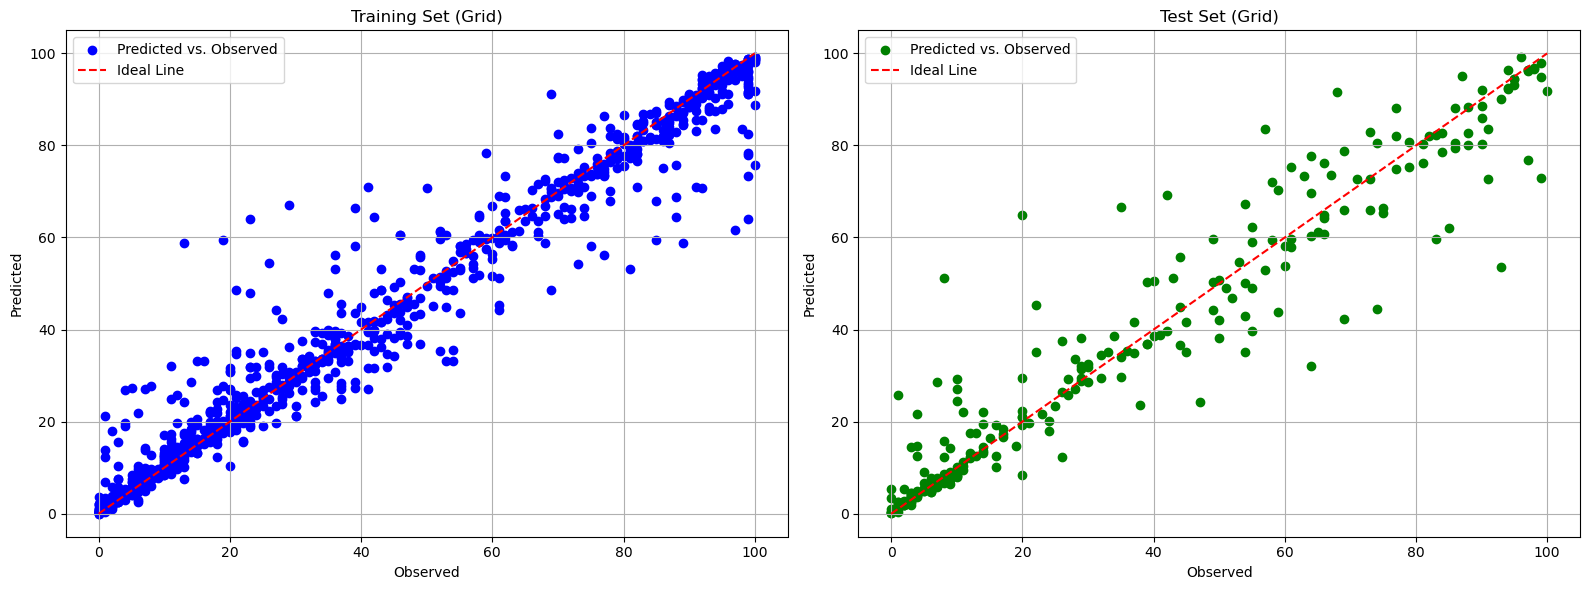

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # width doubled for 2 plots

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid, color='blue', label='Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Training Set (Grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test Set (Grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("RF_pair_grid.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Plot RMSE w.r.t No of trees

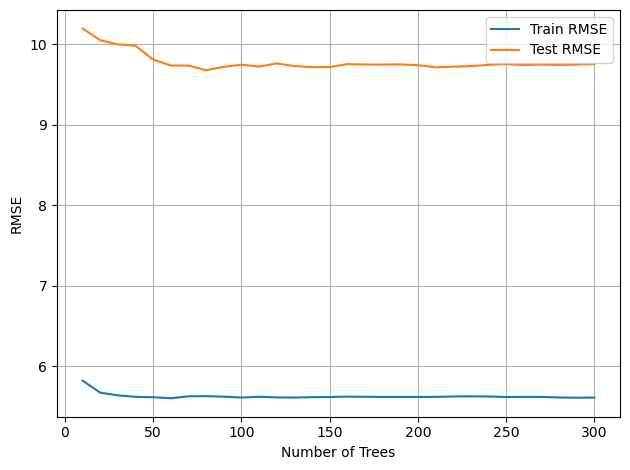

In [82]:
train_rmse = []
test_rmse = []

n_estimators_range = range(10, 301, 10)

for n in n_estimators_range:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=best_params['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_final, y_train_clean)

    y_train_pred = rf.predict(X_train_final)
    y_test_pred = rf.predict(X_test_final)

    train_rmse.append(root_mean_squared_error(y_train_clean, y_train_pred))
    test_rmse.append(root_mean_squared_error(y_test, y_test_pred))

plt.figure()
plt.plot(n_estimators_range, train_rmse, label="Train RMSE")
plt.plot(n_estimators_range, test_rmse, label="Test RMSE")
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("RF_RMSE.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [83]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value = explainer.expected_value

C:\Users\User\AppData\Local\Temp\ipykernel_69044\3709931673.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


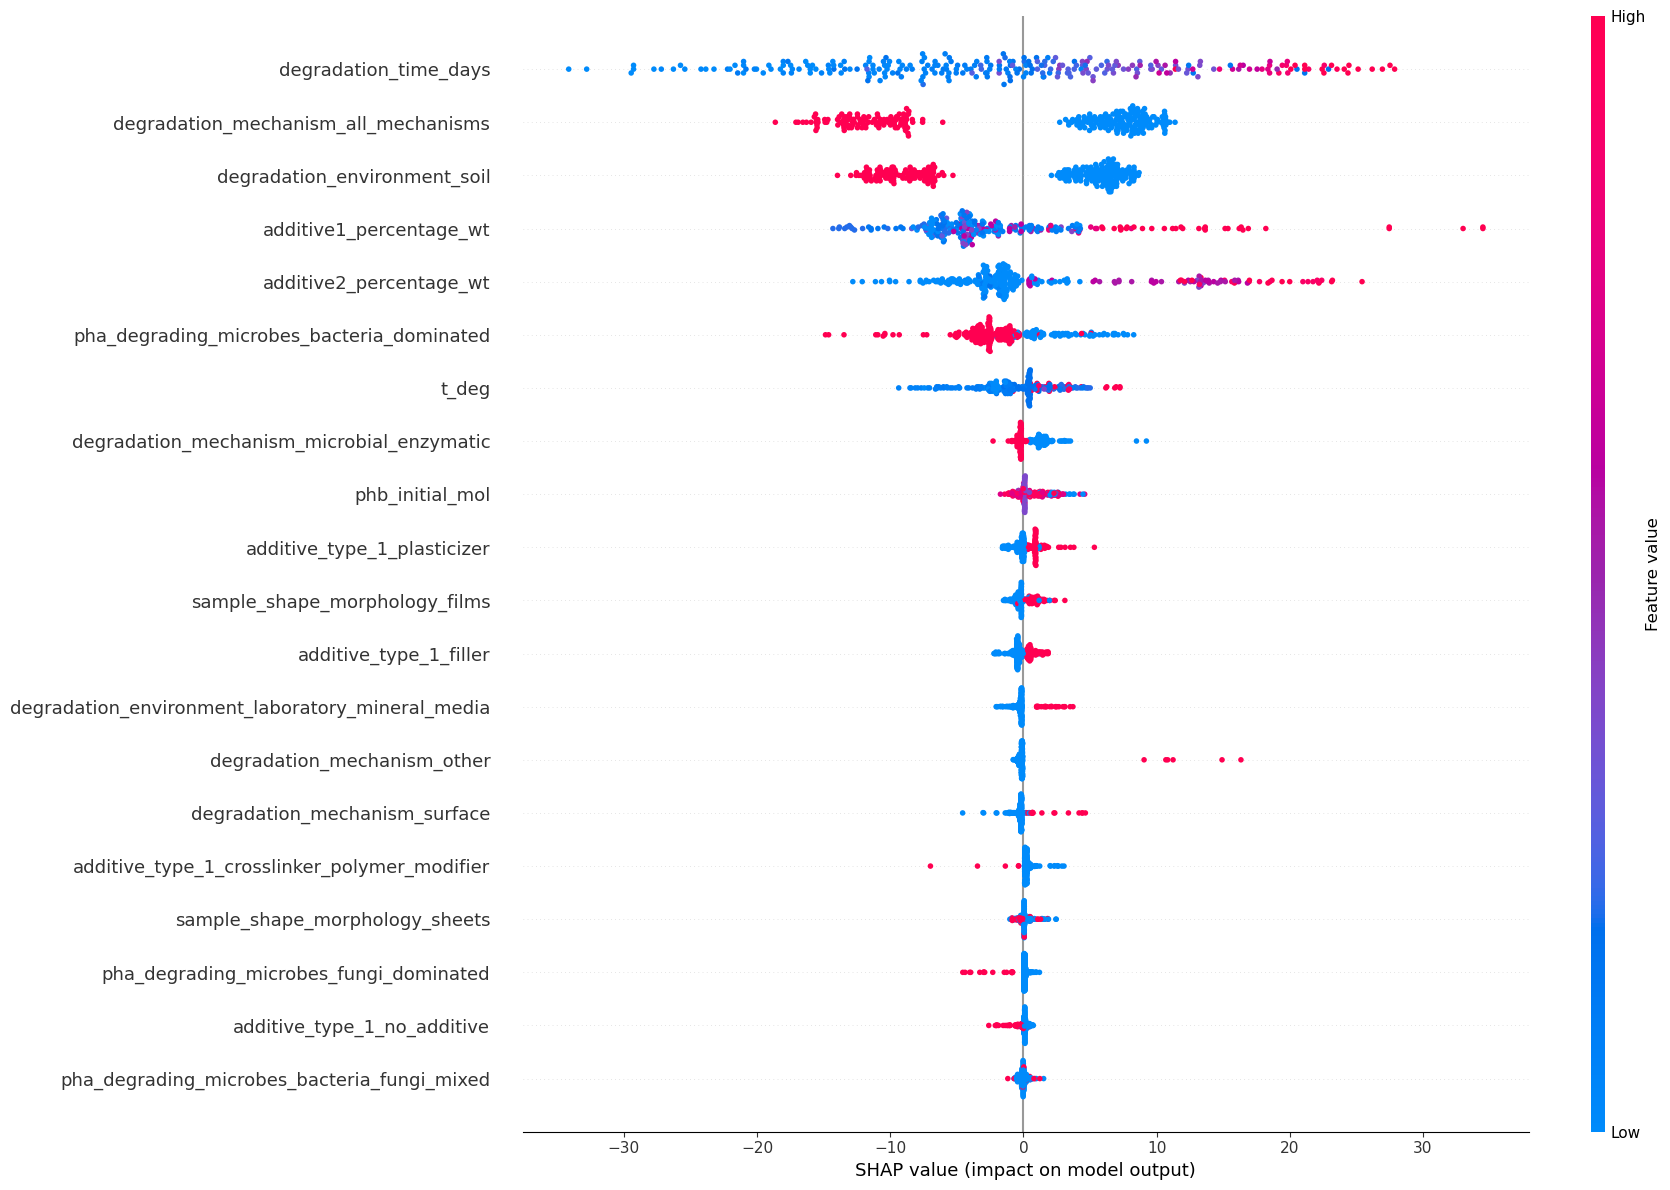

In [84]:
shap.summary_plot(
    shap_values,
    X_test_final,
#    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(18, 12)
)

plt.tight_layout()
plt.savefig("RF_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Grid search - XGBoost

In [85]:
# Define the parameter grid
param_grid = {
     'n_estimators': [200, 400, 800],
    'learning_rate': [0.01, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8]
}

# Initialize the Grid Search with Random Forest
grid_search2 = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search2.fit(X_train_final, y_train_clean)

# Extract the best parameters
best_params2 = grid_search2.best_params_
best_score2 = grid_search2.best_score_

# Print
print(f"Best parameters found: {best_params2}")
print(f"Best R^2 score from Grid Search (CV): {best_score2}")

# Use the best estimator
best_xgb = grid_search2.best_estimator_

# predictions
y_train_pred_grid2 = best_xgb.predict(X_train_final)
y_test_pred_grid2 = best_xgb.predict(X_test_final)

# Metrics
r2_train_grid2 = r2_score(y_train_clean, y_train_pred_grid2)
r2_test_grid2 = r2_score(y_test, y_test_pred_grid2)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid2 = cross_val_score(best_xgb, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid2 = np.mean(cv_scores_r2_grid2)
std_cv_r2_grid2 = np.std(cv_scores_r2_grid2)

# Print the R^2 scores
summary_df2 = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2'],
    'XGBoost (Tuned)': [
        r2_train_grid2,
        r2_test_grid2,
        mean_cv_r2_grid2,
        std_cv_r2_grid2
    ]
})

print(summary_df2)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.0s
[CV] END 

## Plot results

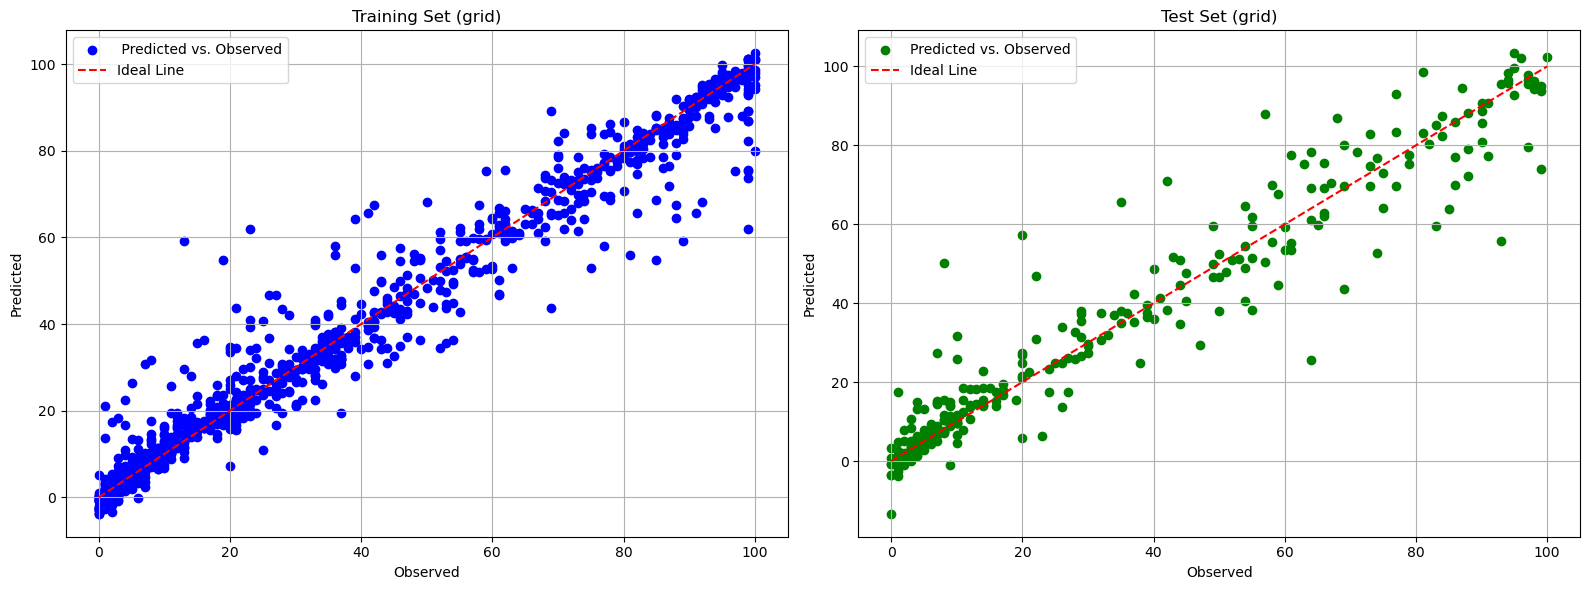

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # width doubled for 2 plots

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid2, color='blue', label=' Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Training Set (grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid2, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Test Set (grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("XGB_pair_grid.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Loss plot

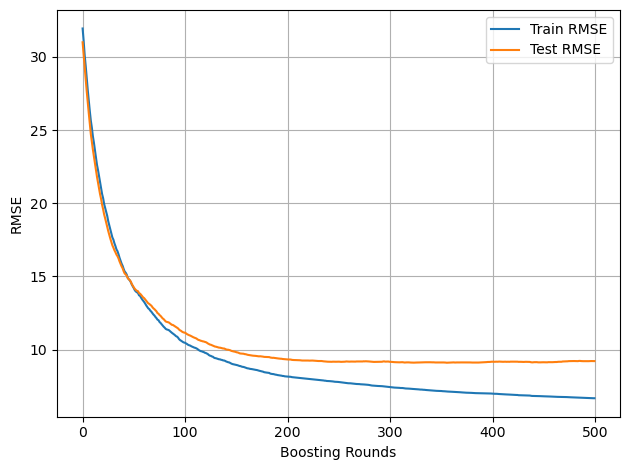

In [87]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=best_params2['max_depth'],
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric=["rmse"],
    random_state=42
)

model.fit(
    X_train_final, y_train_clean,
    eval_set=[(X_train_final, y_train_clean), (X_test_final, y_test)],
    verbose=False
)

results = model.evals_result()

epochs = len(results['validation_0']['rmse'])

plt.figure()
plt.plot(range(epochs), results['validation_0']['rmse'], label="Train RMSE")
plt.plot(range(epochs), results['validation_1']['rmse'], label="Test RMSE")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("XGB_loss.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [88]:
explainer2 = shap.TreeExplainer(best_xgb)
shap_values2 = explainer2.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value2 = explainer2.expected_value

C:\Users\User\AppData\Local\Temp\ipykernel_69044\3763143948.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


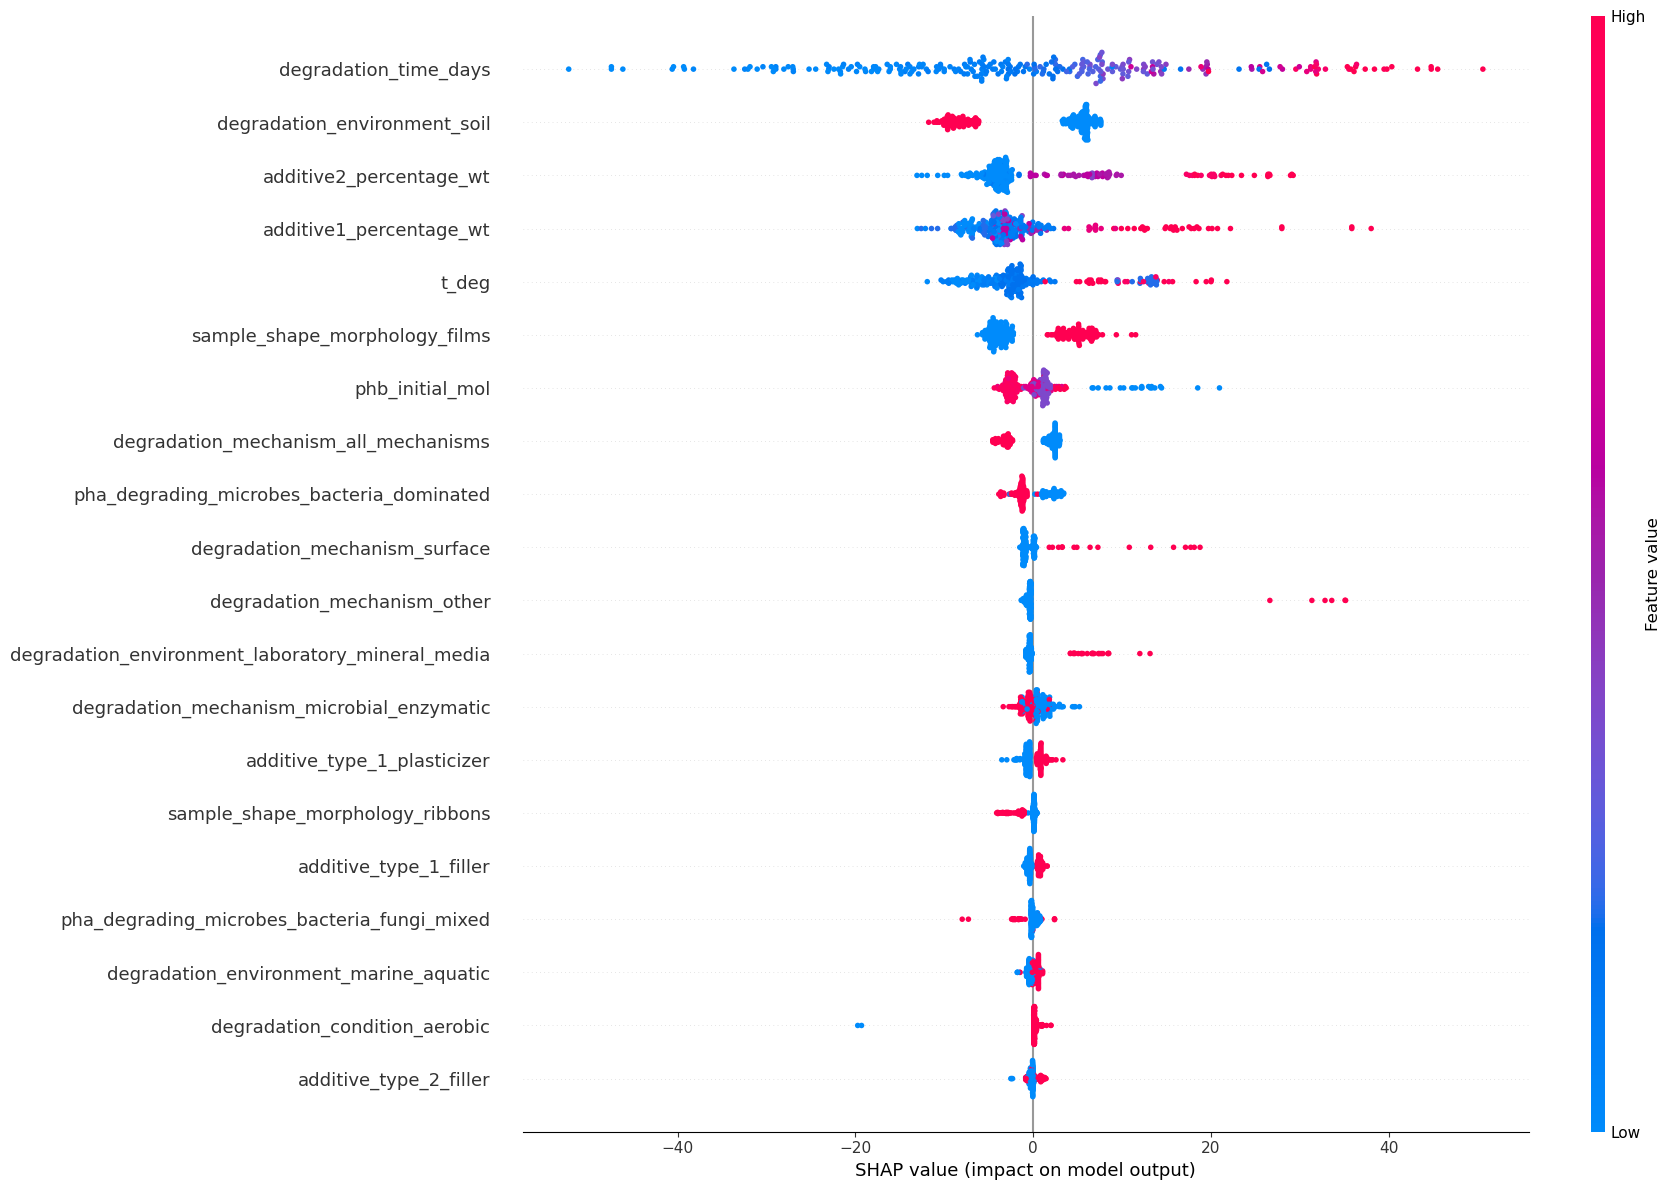

In [89]:
shap.summary_plot(
    shap_values2,
    X_test_final,
 #   max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(18, 12)
)

plt.tight_layout()
plt.savefig("XGB_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Validation check on unseen data (excl. full instances)

In [90]:
# transform validation set
X_val = df_val.drop(columns=[target,'additives','study_id','instance'])
X_val_ohe = ohe.transform(X_val[categorical_cols_lst])
X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_columns, index=X_val.index)
X_val_final = pd.concat([X_val.drop(columns=categorical_cols_lst), X_val_ohe_df], axis=1)
X_val_final = X_val_final[selected_features]

In [91]:
cols = X_val_final.columns.tolist()
first_col = cols.pop(0)

# Insert it at index 2 (third position)
cols.insert(2, first_col)
# X_val_final = X_val_final[cols]
y_val = df_val[target]

# RF
y_val_pred_rf = best_rf.predict(X_val_final)
r2_val_rf = r2_score(y_val, y_val_pred_rf)
print(f'R^2 score on unseen set (RF): {r2_val_rf}')

# XGBoost
y_val_pred_xg = best_xgb.predict(X_val_final)
r2_val_xg = r2_score(y_val, y_val_pred_xg)
print(f'R^2 score on unseen set (xgb): {r2_val_xg}')

R^2 score on unseen set (RF): 0.8210271425586743
R^2 score on unseen set (xgb): 0.9257575983787192


## Results table - RF

In [92]:
# RF
df_eval_rf = pd.DataFrame({
    'pos': np.arange(len(y_val)),
    'study_id': df_val['study_id'].values,
    'instance': df_val['instance'].values,
    'y_test': y_val,
    'y_pred': y_val_pred_rf
})

df_eval_rf['error'] = np.abs(df_eval_rf['y_test'] - df_eval_rf['y_pred'])

best_rows = df_eval_rf.loc[df_eval_rf.groupby('study_id')['error'].idxmin()]
best_rows_sorted = best_rows.sort_values(by='error', ascending=True)
best_rows_sorted

,pos,study_id,instance,y_test,y_pred,error
398,4,12.0,4,2.0,1.972944,0.027056
625,42,13.0,5,1.0,0.884333,0.115667
1448,149,21.0,5,94.0,93.647327,0.352673
834,96,15.0,6,59.0,58.561254,0.438746
1034,127,18.0,3b,91.0,92.431558,1.431558
1490,153,24.0,7,33.0,29.696407,3.303593


## Plot results - RF

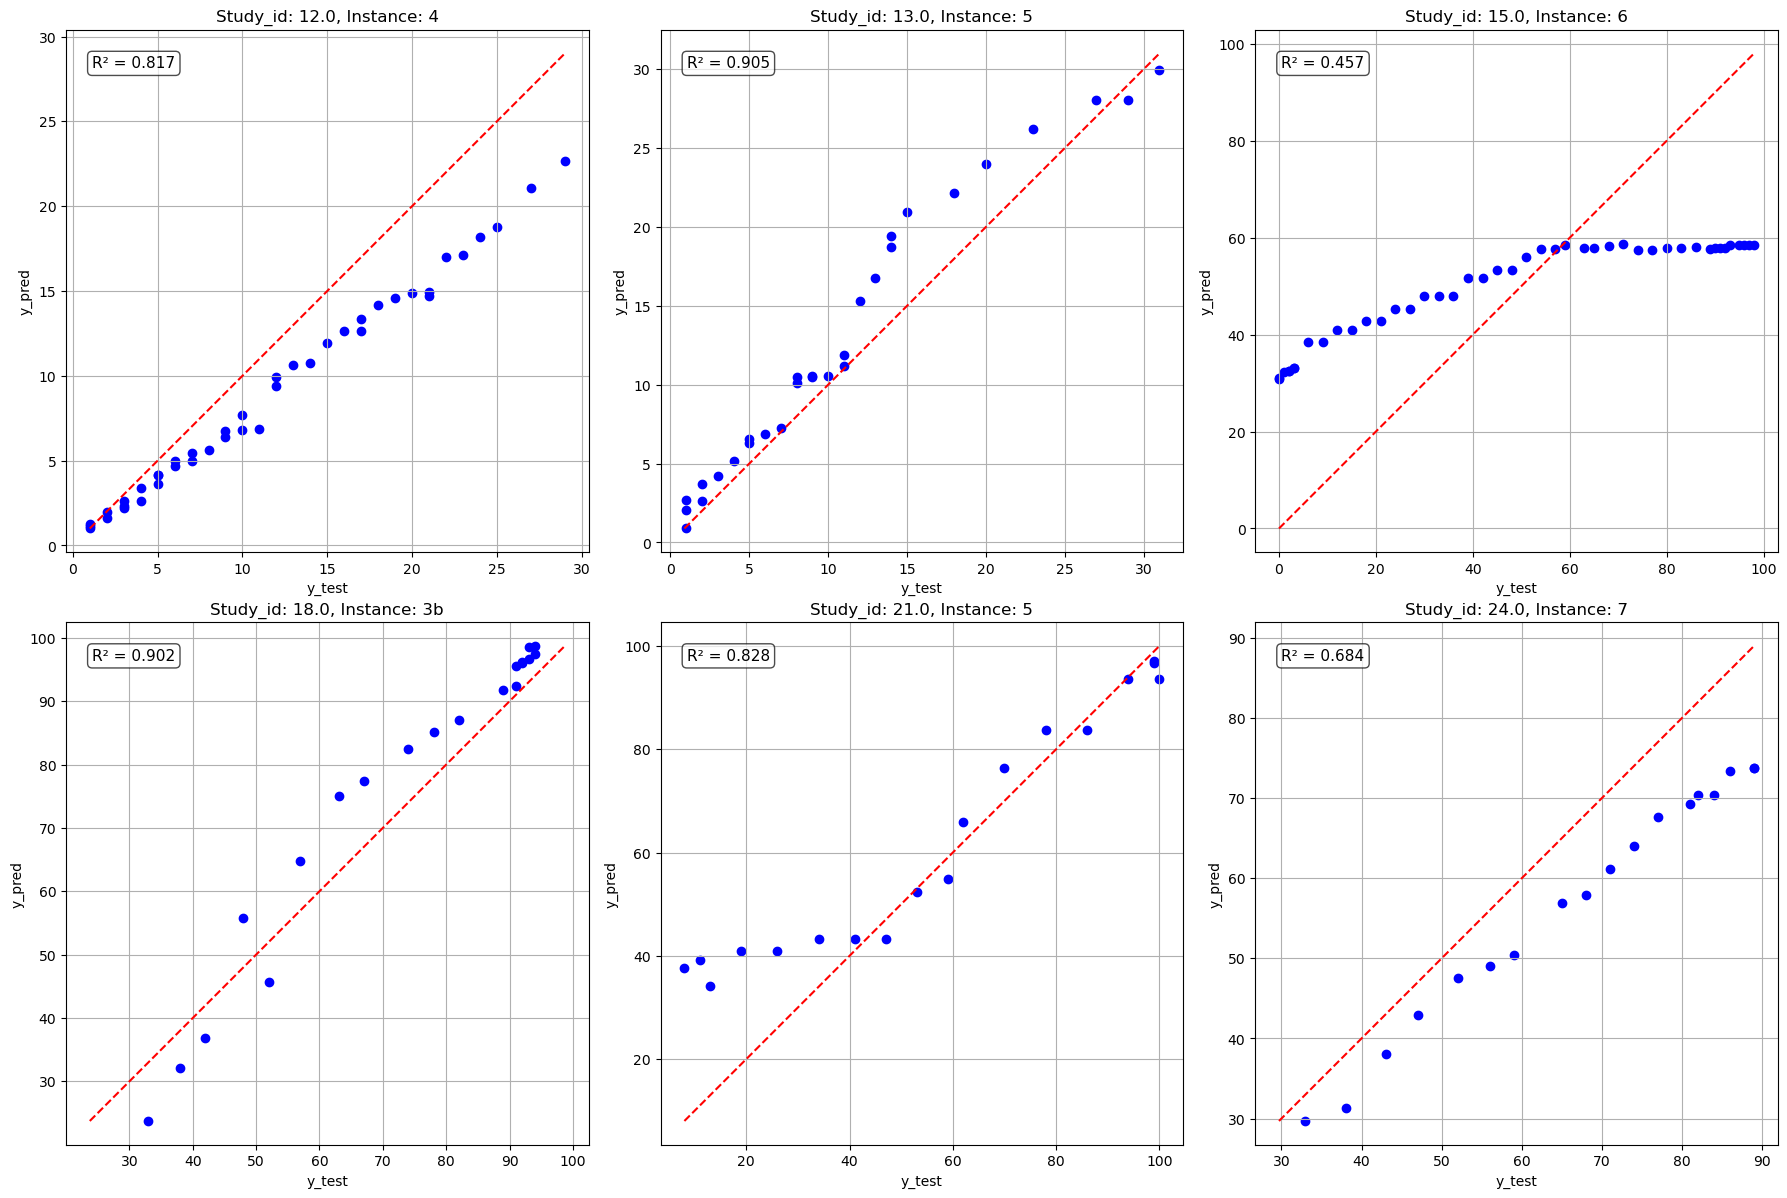

In [94]:
study_ids = df_eval_rf['study_id'].unique().tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, study_id in zip(axes, study_ids):
    ax.clear() 

    subset = df_eval_rf[df_eval_rf['study_id'] == study_id]

    r2 = r2_score(subset['y_test'], subset['y_pred'])

    ax.scatter(subset['y_test'], subset['y_pred'], color='blue')

    min_val = min(subset['y_test'].min(), subset['y_pred'].min())
    max_val = max(subset['y_test'].max(), subset['y_pred'].max())

    instance = subset['instance'].iloc[0]

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(f'Study_id: {study_id}, Instance: {instance}')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    ax.text(
        0.05, 0.95,
        f'R² = {r2:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()

In [95]:
# XGBoost
df_eval_xg = pd.DataFrame({
    'pos': np.arange(len(y_val)),
    'study_id': df_val['study_id'].values,
    'instance': df_val['instance'].values,
    'y_test': y_val,
    'y_pred': y_val_pred_xg
})

df_eval_xg['error'] = np.abs(df_eval_xg['y_test'] - df_eval_xg['y_pred'])

best_rows2 = df_eval_xg.loc[df_eval_xg.groupby('study_id')['error'].idxmin()]
best_rows_sorted2 = best_rows2.sort_values(by='error', ascending=True)
best_rows_sorted2

,pos,study_id,instance,y_test,y_pred,error
636,53,13.0,5,8.0,8.009045,0.009045
1490,153,24.0,7,33.0,33.112164,0.112164
1023,116,18.0,3b,38.0,38.281487,0.281487
1449,150,21.0,5,100.0,99.650925,0.349075
840,102,15.0,6,77.0,77.606682,0.606682
395,1,12.0,4,1.0,-0.002710,1.002710


## Plot results - XGBoost

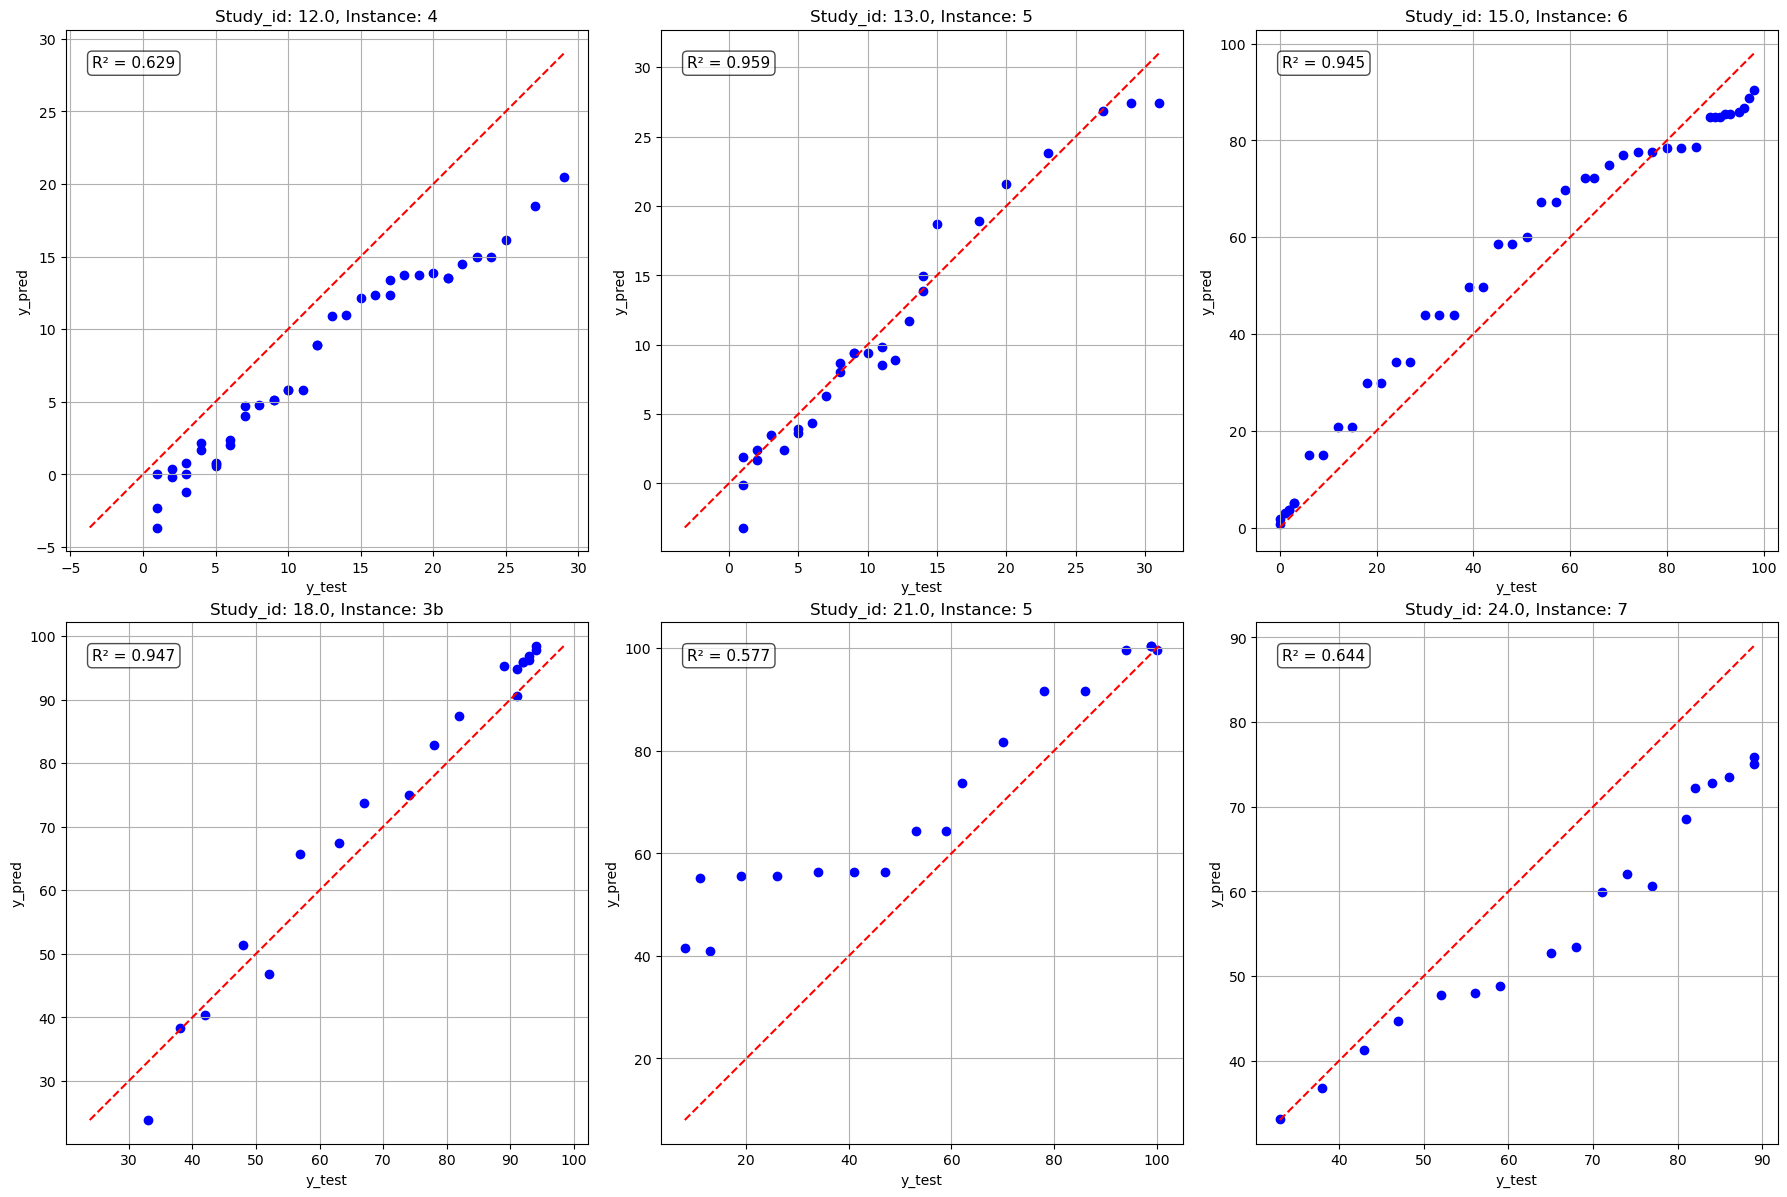

In [96]:
study_ids = df_eval_xg['study_id'].unique().tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, study_id in zip(axes, study_ids):
    ax.clear() 

    subset = df_eval_xg[df_eval_xg['study_id'] == study_id]

    r2 = r2_score(subset['y_test'], subset['y_pred'])

    ax.scatter(subset['y_test'], subset['y_pred'], color='blue')

    min_val = min(subset['y_test'].min(), subset['y_pred'].min())
    max_val = max(subset['y_test'].max(), subset['y_pred'].max())

    instance = subset['instance'].iloc[0]

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(f'Study_id: {study_id}, Instance: {instance}')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    ax.text(
        0.05, 0.95,
        f'R² = {r2:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()

## Plot best model

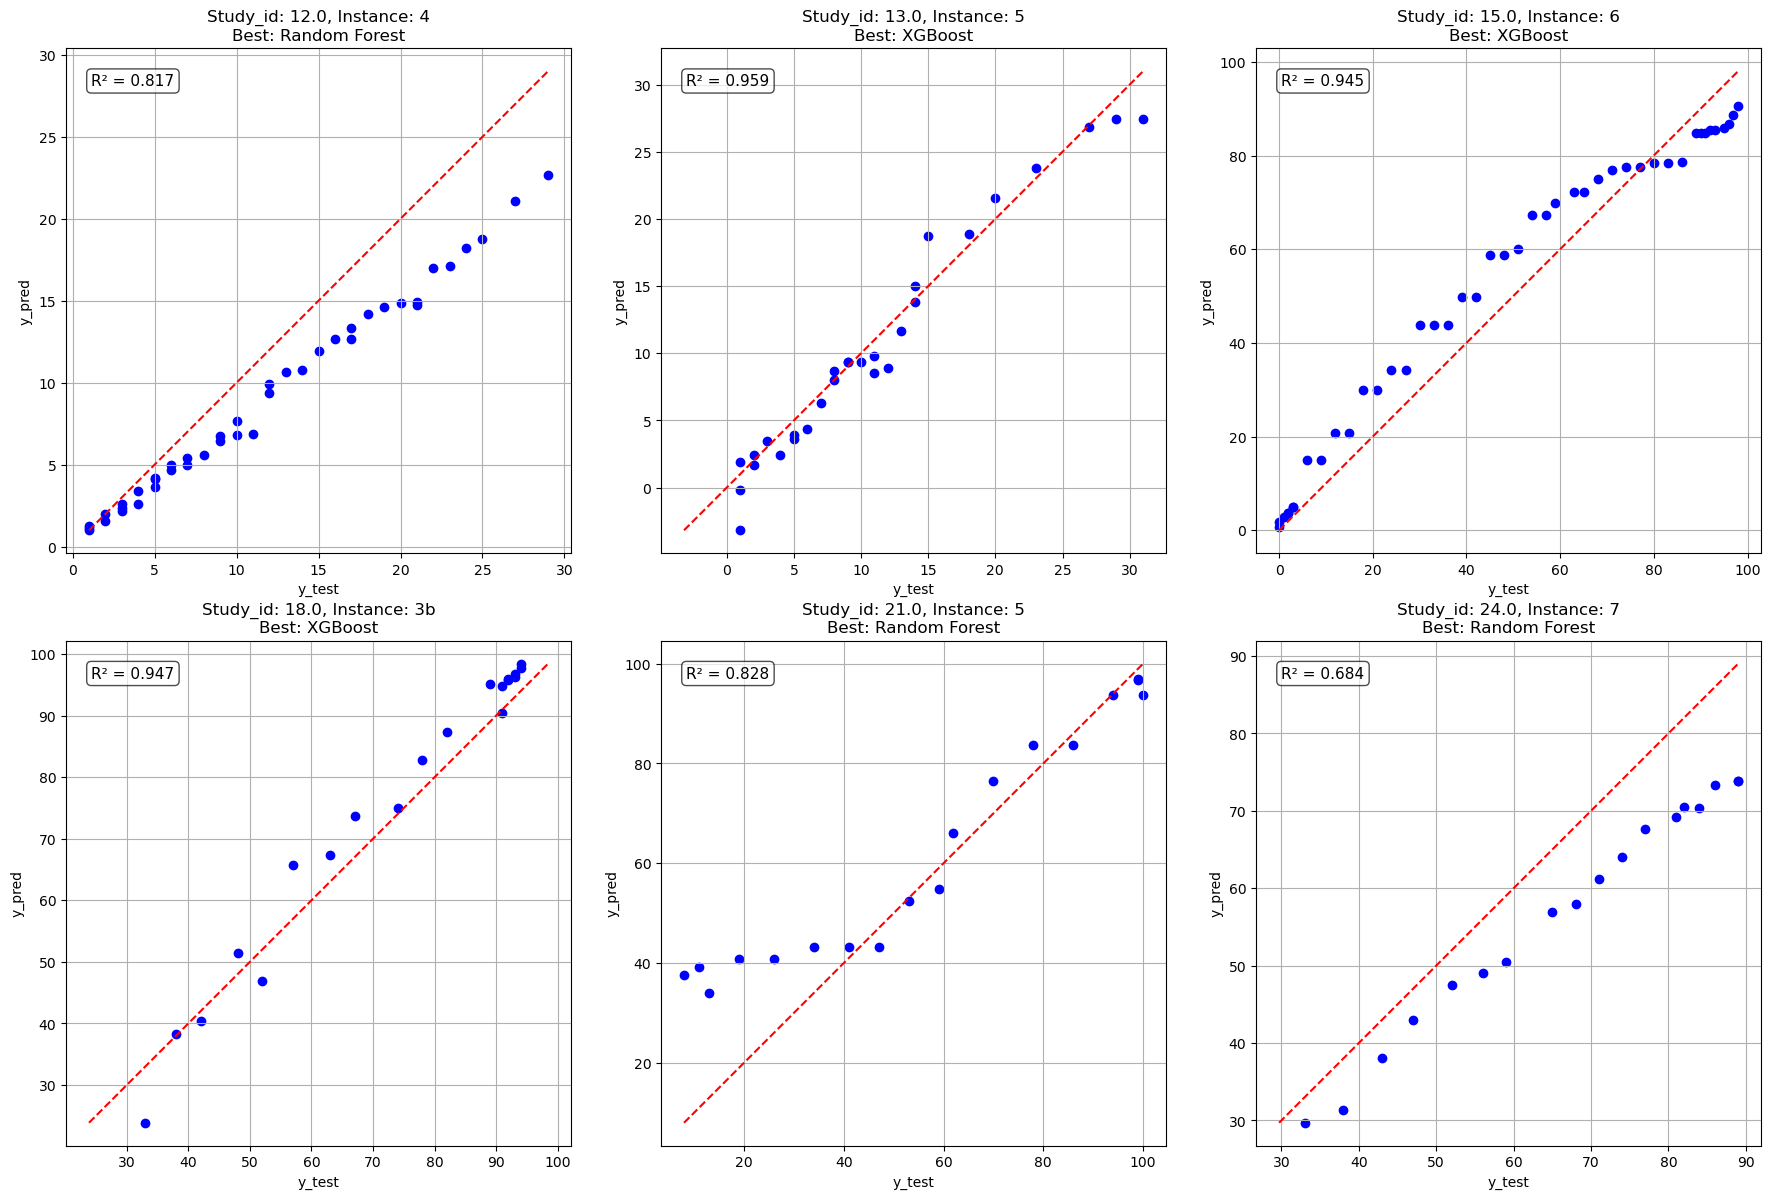

In [97]:
# Combine study IDs from both datasets
study_ids = df_val['study_id'].unique()

# Prepare figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, study_id in zip(axes, study_ids):
    ax.clear()

    # Subset for both models
    subset_xg = df_eval_xg[df_eval_xg['study_id'] == study_id]
    subset_rf = df_eval_rf[df_eval_rf['study_id'] == study_id]

    # Compute R² for both models
    r2_xg = r2_score(subset_xg['y_test'], subset_xg['y_pred']) if not subset_xg.empty else float('-inf')
    r2_rf = r2_score(subset_rf['y_test'], subset_rf['y_pred']) if not subset_rf.empty else float('-inf')

    # Choose the best model
    if r2_xg >= r2_rf:
        best_subset = subset_xg
        best_model = 'XGBoost'
        best_r2 = r2_xg
    else:
        best_subset = subset_rf
        best_model = 'Random Forest'
        best_r2 = r2_rf

    # Plot
    ax.scatter(best_subset['y_test'], best_subset['y_pred'], color='blue')

    min_val = min(best_subset['y_test'].min(), best_subset['y_pred'].min())
    max_val = max(best_subset['y_test'].max(), best_subset['y_pred'].max())

    instance = best_subset['instance'].iloc[0]

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
    ax.set_title(f'Study_id: {study_id}, Instance: {instance}\nBest: {best_model}')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    ax.text(
        0.05, 0.95,
        f'R² = {best_r2:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()  # prevent overlap
plt.savefig('unseen_excl2.tiff', format='tiff', dpi=300)
plt.show()

## Jaqpot

In [23]:
df_final.columns

Index(['phb_initial_mol', 'degradation_time_days', 'degradation_condition',
       'degradation_mechanism', 't_deg', 'degradation_environment',
       'additive_type_1', 'additive1_percentage_wt', 'additive_type_2',
       'additive2_percentage_wt', 'additive_type_3', 'additive3_percentage_wt',
       'pha_degrading_microbes', 'sample_shape_morphology',
       'experimental_scale', 'weight_loss'],
      dtype='object')

In [24]:
numerical_cols_lst = (
    df_final
    .select_dtypes(include=[np.number])
    .columns
    .difference(['additive3_percentage_wt'])
    .tolist()
)

categorical_cols_lst = (
    df_final
    .select_dtypes(include=['object', 'category'])
    .columns
    .difference(['additive_type_3'])
    .tolist()
)

exclude_cols = [
    'additive_type_3',
    'additive3_percentage_wt'
]

In [25]:
numerical_cols_lst.remove(target)
features_num = numerical_cols_lst
features_cat = categorical_cols_lst

In [26]:
X_train_clean = X_train_clean.drop(columns=exclude_cols, errors='ignore')
df_train = X_train_clean.copy()
df_train[target] = y_train_clean

train_dataset = JaqpotTabularDataset(
    df=df_train,
    x_cols=X_train_clean.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

In [27]:
X_test = X_test.drop(columns=exclude_cols, errors='ignore')
df_test = X_test.copy()
df_test[target] = y_test

test_dataset = JaqpotTabularDataset(
    df=df_test,
    x_cols=X_test.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

In [28]:
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_features', StandardScaler(), features_num),
        ('categorical_features', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), features_cat)
    ],
    remainder='drop',
)

In [29]:
model = RandomForestRegressor(random_state=42, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300)
jaqpot_model = SklearnModel(
    dataset=train_dataset,
    model=model,
    doa=[Leverage(), BoundingBox()],
    preprocess_x=preprocessing,
  )

jaqpot_model.random_seed = 1231
jaqpot_model.fit()

Goodness-of-fit metrics on training set:
{'r2': 0.971064223904941, 'mae': 2.625495540063992, 'rmse': 5.615393457349662}


In [30]:
# Perform cross-validation on the training data
jaqpot_model.cross_validate(train_dataset, n_splits=10)

{'r2': 0.8944228035749449,
 'mae': 5.614283354848978,
 'rmse': 10.512967381579495}

In [31]:
# Evaluate the model on the test dataset
jaqpot_model.evaluate(test_dataset)

{'r2': 0.9078927291248805,
 'mae': 5.2580583609512175,
 'rmse': 9.703595813183082}

In [32]:
# Conducts a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'r2': 0.7538052317445731,
   'mae': 12.874046589213254,
   'rmse': 16.379552558385356},
  'Test': {'r2': -0.2561995734056466,
   'mae': 30.008151031067698,
   'rmse': 35.83563149644641}},
 'iteration_1': {'Train': {'r2': 0.7583350559505999,
   'mae': 12.865580409339337,
   'rmse': 16.228166396943852},
  'Test': {'r2': -0.2650698338096642,
   'mae': 29.361479000717097,
   'rmse': 35.961929986329}},
 'iteration_2': {'Train': {'r2': 0.7403164427617612,
   'mae': 13.466711001300288,
   'rmse': 16.822279710286086},
  'Test': {'r2': -0.2522860805040459,
   'mae': 30.59218836895028,
   'rmse': 35.77976780694935}},
 'iteration_3': {'Train': {'r2': 0.7490276421119034,
   'mae': 12.913587585914966,
   'rmse': 16.537717520247078},
  'Test': {'r2': -0.4092375781720401,
   'mae': 32.26034843111034,
   'rmse': 37.95577372655546}},
 'iteration_4': {'Train': {'r2': 0.7409884209527123,
   'mae': 13.325707471210446,
   'rmse': 16.80050026532666},
  'Test': {'r2': -0.2403397035

In [33]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)
print(doa_predictions)

{'LEVERAGE': [{'h': 0.006713981130324288, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.005985067510099773, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.014616733217295442, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.010812877118373615, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.011395636568228866, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.01057217456884321, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.01857203736208287, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.008880521118465476, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.008116778035781433, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.00978752398605635, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.012414567895549362, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.01428072409592519, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.007369312530349795, 'hStar': 0.09340659340659341, 'inDoa': True}, {'h': 0.015870816700548903, 

In [34]:
summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary

{'LEVERAGE': {'n_total': 273, 'n_in': 259, 'n_out': 14},
 'BOUNDING_BOX': {'n_total': 273, 'n_in': 273, 'n_out': 0}}

## Upload model

In [35]:
# Upload the pretrained model on Jaqpot
jaqpot = Jaqpot()
jaqpot.login()
jaqpot_model.deploy_on_jaqpot(
    jaqpot=jaqpot,
    name="Weight or mass loss regression model A.N.I.P.H. (v2)",
    description="Prediction of weight or mass loss percentage of PHBV polymers.",
    visibility="PUBLIC",
)

Open this URL in your browser and log in:
https://login.jaqpot.org/realms/jaqpot/protocol/openid-connect/auth?client_id=jaqpot-client&response_type=code&redirect_uri=urn:ietf:wg:oauth:2.0:oob&scope=openid email profile&state=random_state_value&nonce=


Enter the authorization code you received:  ········


  2026-06-23 20:52:26,299 - INFO - Large model detected, using /v1/large-models flow
  2026-06-23 20:52:28,385 - INFO - Uploading your model directly to s3, due to its large size...
Uploading: 100%|█████████▉| 12.8M/12.8M [00:09<00:00, 1.30MB/s]

✅ File uploaded successfully.


Uploading: 100%|██████████| 12.8M/12.8M [00:10<00:00, 1.20MB/s]
  2026-06-23 20:52:39,262 - INFO - Model has been successfully uploaded. The url of the model is https://app.jaqpot.org/dashboard/models/2378


In [36]:
df_train[features_num].agg(['min', 'max'])

,additive1_percentage_wt,additive2_percentage_wt,degradation_time_days,phb_initial_mol,t_deg
min,0.0,0.0,0.0,81.9,20.0
max,70.0,50.0,360.0,99.0,60.0


In [37]:
df_train.head()

,phb_initial_mol,degradation_time_days,degradation_condition,degradation_mechanism,t_deg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,pha_degrading_microbes,sample_shape_morphology,experimental_scale,weight_loss
1133,88.0,103.0,aerobic,microbial_enzymatic,27.0,marine_aquatic,plasticizer,7.0,filler,30.0,bacteria_dominated,ribbons,large,27.0
856,97.0,30.0,aerobic,microbial_enzymatic,21.0,compost_organic_fertilizer,plasticizer,10.0,no_additive,0.0,diverse_environmental,films,lab,18.0
1533,98.0,148.0,aerobic,hydrolysis,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,diverse_environmental,films,lab,75.0
1005,88.0,103.0,aerobic,microbial_enzymatic,29.0,marine_aquatic,plasticizer,5.0,filler,50.0,bacteria_dominated,ribbons,large,82.0
1183,88.0,33.0,aerobic,microbial_enzymatic,26.0,marine_aquatic,plasticizer,10.0,no_additive,0.0,bacteria_dominated,ribbons,large,3.0
